# Marketplace Analytics Platform
## Notebook 3 — Exploratory Data Analysis

This notebook profiles the statistical shape and visual distribution of the Olist dataset, building on the structural profile established in `01_data_assessment.ipynb`. It covers descriptive statistics for all meaningful numeric and categorical columns, followed immediately by visual analysis — histograms and boxplots for numeric distributions and bar charts for categorical frequencies. Anomalies surfaced by the summary tables are flagged inline and cross-referenced to their investigations in `02_data_quality_check.ipynb`.

In [1]:
import sys
sys.path.append("../python")

from utils.imports import *
from utils.load_data import load_datasets
from utils.date_conversion import convert_dates

dfs = load_datasets()
dfs = convert_dates(dfs)

### EDA on Numeric columns

#### **Numeric Summary**

In [2]:
numeric_summary = []

for name, df in dfs.items():
    numeric_columns = df.select_dtypes(include=np.number).columns

    for col in numeric_columns:
        if df[col].dtype == bool:
            continue

        col_lower = col.lower()
        is_identifier_like = (
            col_lower.endswith("_id")
            or col_lower.endswith("_zip_code_prefix")
            or col_lower.endswith("_sequential")
            or col_lower.endswith("_item_id")
        )

        if is_identifier_like:
            continue

        numeric_summary.append({
            "dataset": name,
            "column": col,
            "count": df[col].count(),
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "min": df[col].min(),
            "q1": df[col].quantile(0.25),
            "q3": df[col].quantile(0.75),
            "max": df[col].max()
        })

pd.DataFrame(numeric_summary)

,dataset,column,count,mean,median,std,min,q1,q3,max
0,order_items,price,112650,120.65,74.99,183.63,0.85,39.90,134.90,"6,735.00"
1,order_items,freight_value,112650,19.99,16.26,15.81,0.00,13.08,21.15,409.68
2,payments,payment_installments,103886,2.85,1.00,2.69,0.00,1.00,4.00,24.00
3,payments,payment_value,103886,154.10,100.00,217.49,0.00,56.79,171.84,"13,664.08"
4,reviews,review_score,99224,4.09,5.00,1.35,1.00,4.00,5.00,5.00
5,products,product_name_lenght,32341,48.48,51.00,10.25,5.00,42.00,57.00,76.00
6,products,product_description_lenght,32341,771.50,595.00,635.12,4.00,339.00,972.00,"3,992.00"
7,products,product_photos_qty,32341,2.19,1.00,1.74,1.00,1.00,3.00,20.00
8,products,product_weight_g,32949,"2,276.47",700.00,"4,282.04",0.00,300.00,"1,900.00","40,425.00"
9,products,product_length_cm,32949,30.82,25.00,16.91,7.00,18.00,38.00,105.00


> **⚑ Quality Flag — `geolocation_lat/lng` out of range:** `geolocation_lat` max of 45.07 and `geolocation_lng` ranging from -101.47 to 121.11 fall outside Brazil's geographic bounding box. Investigated in `02_data_quality_check.ipynb` → *Investigating geolocation lat/lng outliers*.

> **⚑ Quality Flag — `payment_installments` minimum = 0:** A payment with 0 installments is logically invalid — even a lump-sum payment should register as 1. Investigated in `02_data_quality_check.ipynb` → *Investigating payment_installments = 0*.

> **⚑ Quality Flag — `product_weight_g` minimum = 0:** A physical product weighing zero grams is not realistic and likely represents a data entry gap. Investigated in `02_data_quality_check.ipynb` → *Investigating product_weight_g = 0*.

> **⚑ Quality Flag — extreme values in `price` and `payment_value`:** `price` reaches BRL 6,735 and `payment_value` reaches BRL 13,664. These are inspected to confirm whether they represent legitimate high-value transactions or data entry errors. Investigated in `02_data_quality_check.ipynb` → *Extreme value inspection*.

#### **Numeric Distributions**

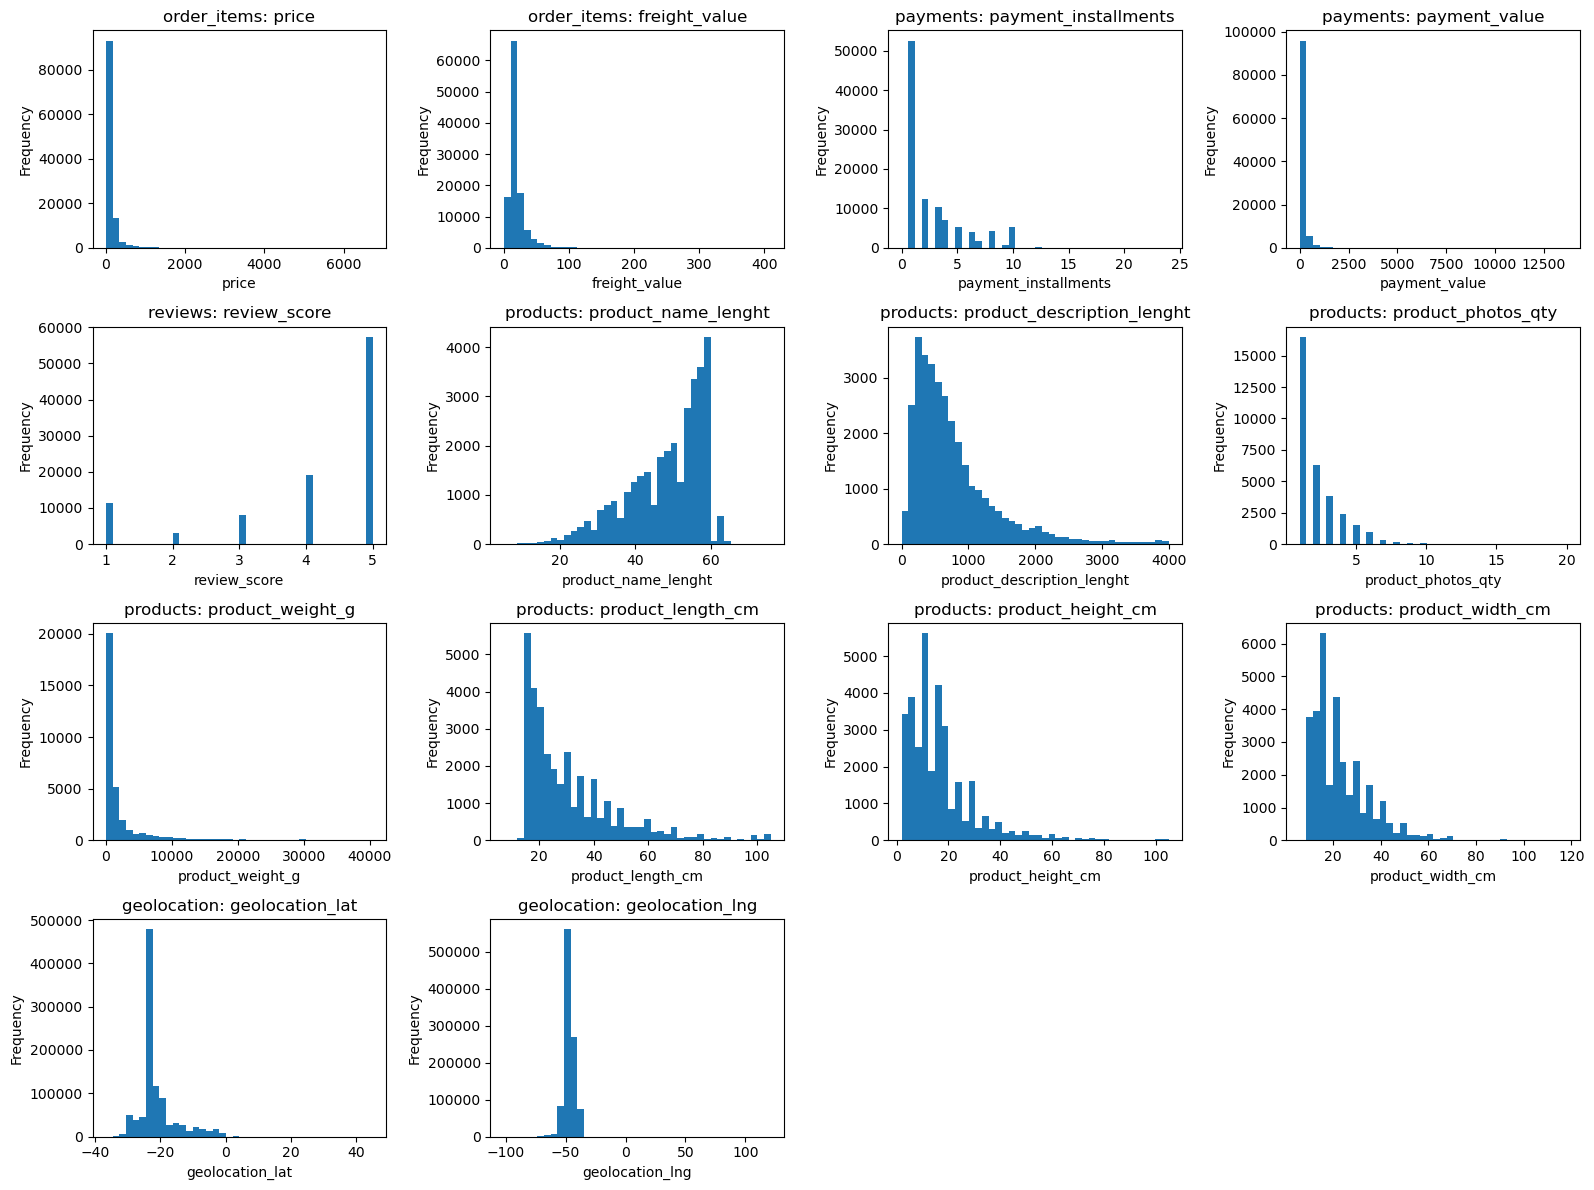

In [3]:
numeric_profile_columns = [
    {"dataset": row["dataset"], "column": row["column"]}
    for row in numeric_summary
]

n_cols = 4
n_rows = int(np.ceil(len(numeric_profile_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, item in enumerate(numeric_profile_columns):

    dataset = item["dataset"]
    column = item["column"]

    axes[i].hist(dfs[dataset][column].dropna(), bins=40)

    axes[i].set_title(f"{dataset}: {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#### **Numeric Outlier Review**

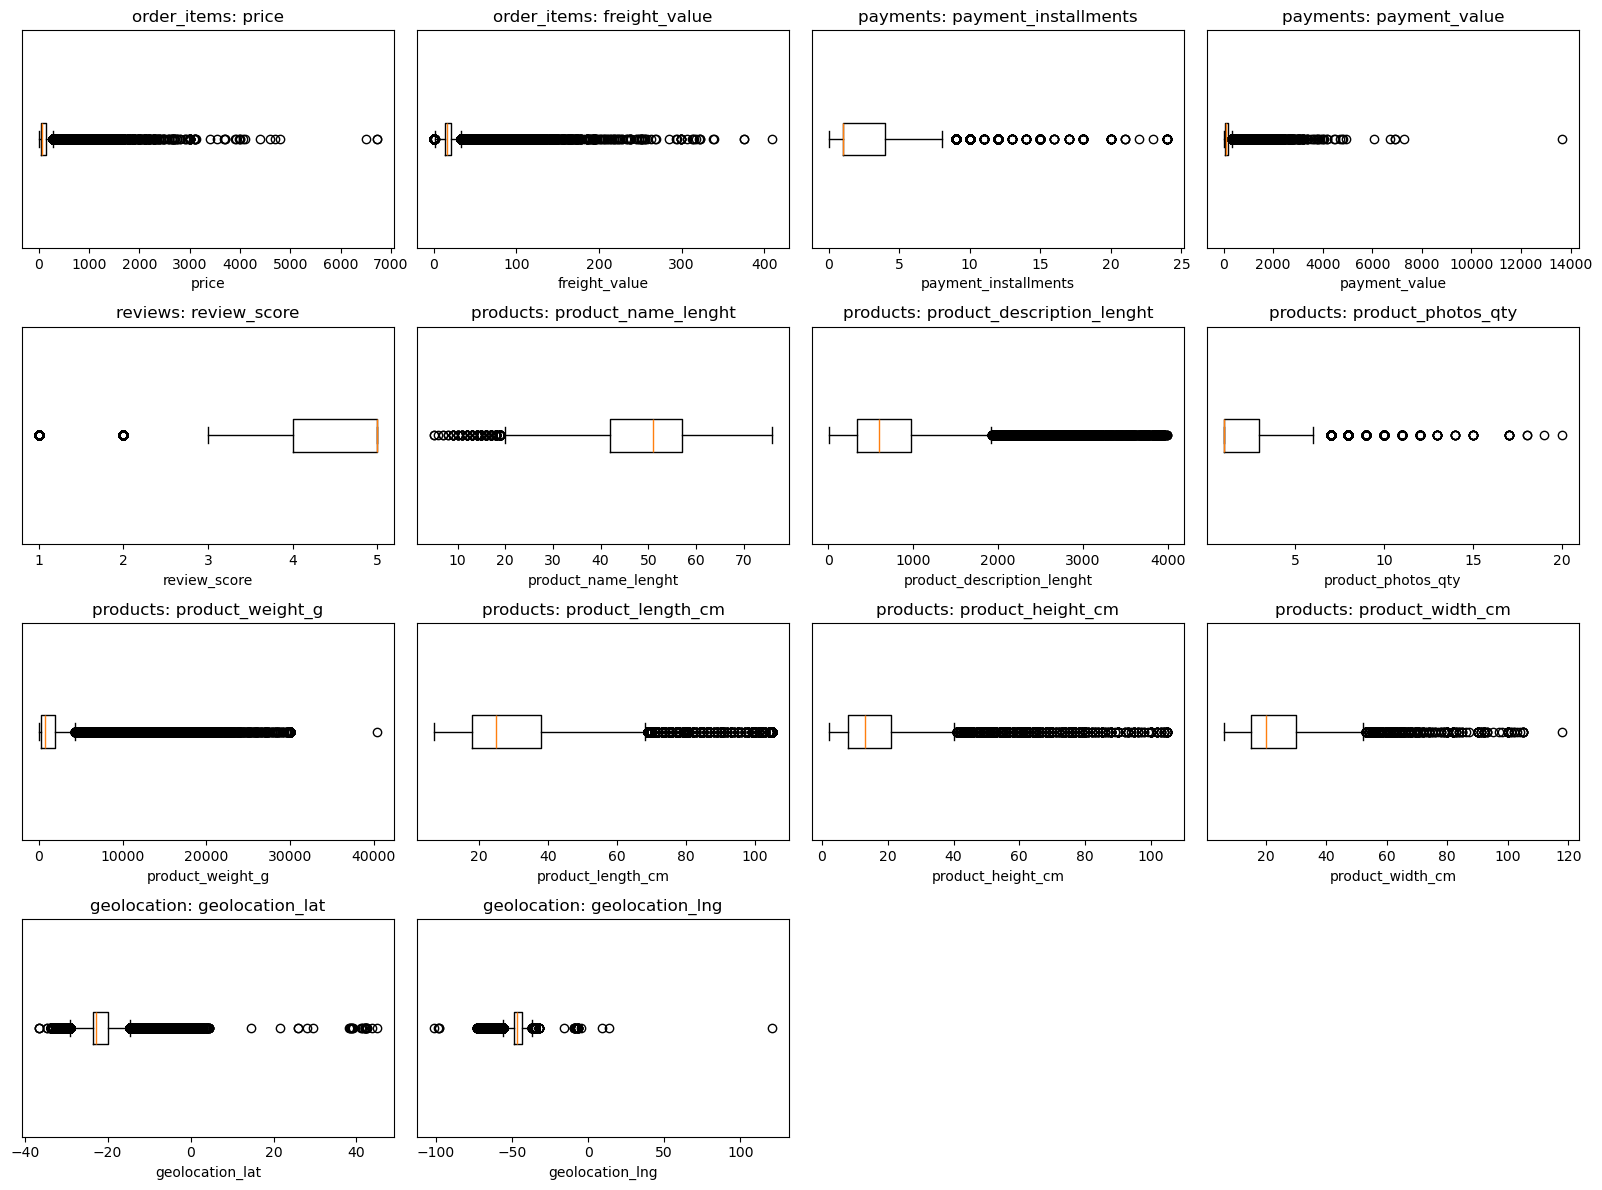

In [4]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, item in enumerate(numeric_profile_columns):

    dataset = item["dataset"]
    column = item["column"]

    axes[i].boxplot(dfs[dataset][column].dropna(), vert=False)

    axes[i].set_title(f"{dataset}: {column}")
    axes[i].set_xlabel(column)
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### EDA on Categorical Columns

#### **Categorical Summary**

In [5]:
excluded_tables = {"category_translation"}
excluded_columns = {"review_comment_title", "review_comment_message"}

categorical_summary = []

for table, df in dfs.items():
    if table in excluded_tables:
        continue

    categorical_columns = [
        col for col in df.select_dtypes(include="object").columns
        if not (
            col.lower().endswith("_id")
            or col.lower() == "id"
            or "id" in col.lower()
            or col in excluded_columns
        )
    ]

    for col in categorical_columns:
        value_counts = df[col].value_counts(dropna=True)

        categorical_summary.append({
            "dataset": table,
            "column": col,
            "unique_values": df[col].nunique(dropna=True),
            "most_frequent_value": value_counts.index[0] if not value_counts.empty else np.nan,
            "most_frequent_count": value_counts.iloc[0] if not value_counts.empty else np.nan
        })

categorical_summary_df = pd.DataFrame(categorical_summary)

categorical_summary_df

,dataset,column,unique_values,most_frequent_value,most_frequent_count
0,orders,order_status,8,delivered,96478
1,customers,customer_city,4119,sao paulo,15540
2,customers,customer_state,27,SP,41746
3,payments,payment_type,5,credit_card,76795
4,products,product_category_name,73,cama_mesa_banho,3029
5,sellers,seller_city,611,sao paulo,694
6,sellers,seller_state,23,SP,1849
7,geolocation,geolocation_city,8011,sao paulo,135800
8,geolocation,geolocation_state,27,SP,404268


> **⚑ Quality Flag — product category translation mismatch:** `products.product_category_name` contains 73 distinct categories but `category_translation` maps only 71, implying 2 category names have no English translation. Investigated in `02_data_quality_check.ipynb` → *Investigating product category translation mismatch*.

#### **Categorical Distribution Review**

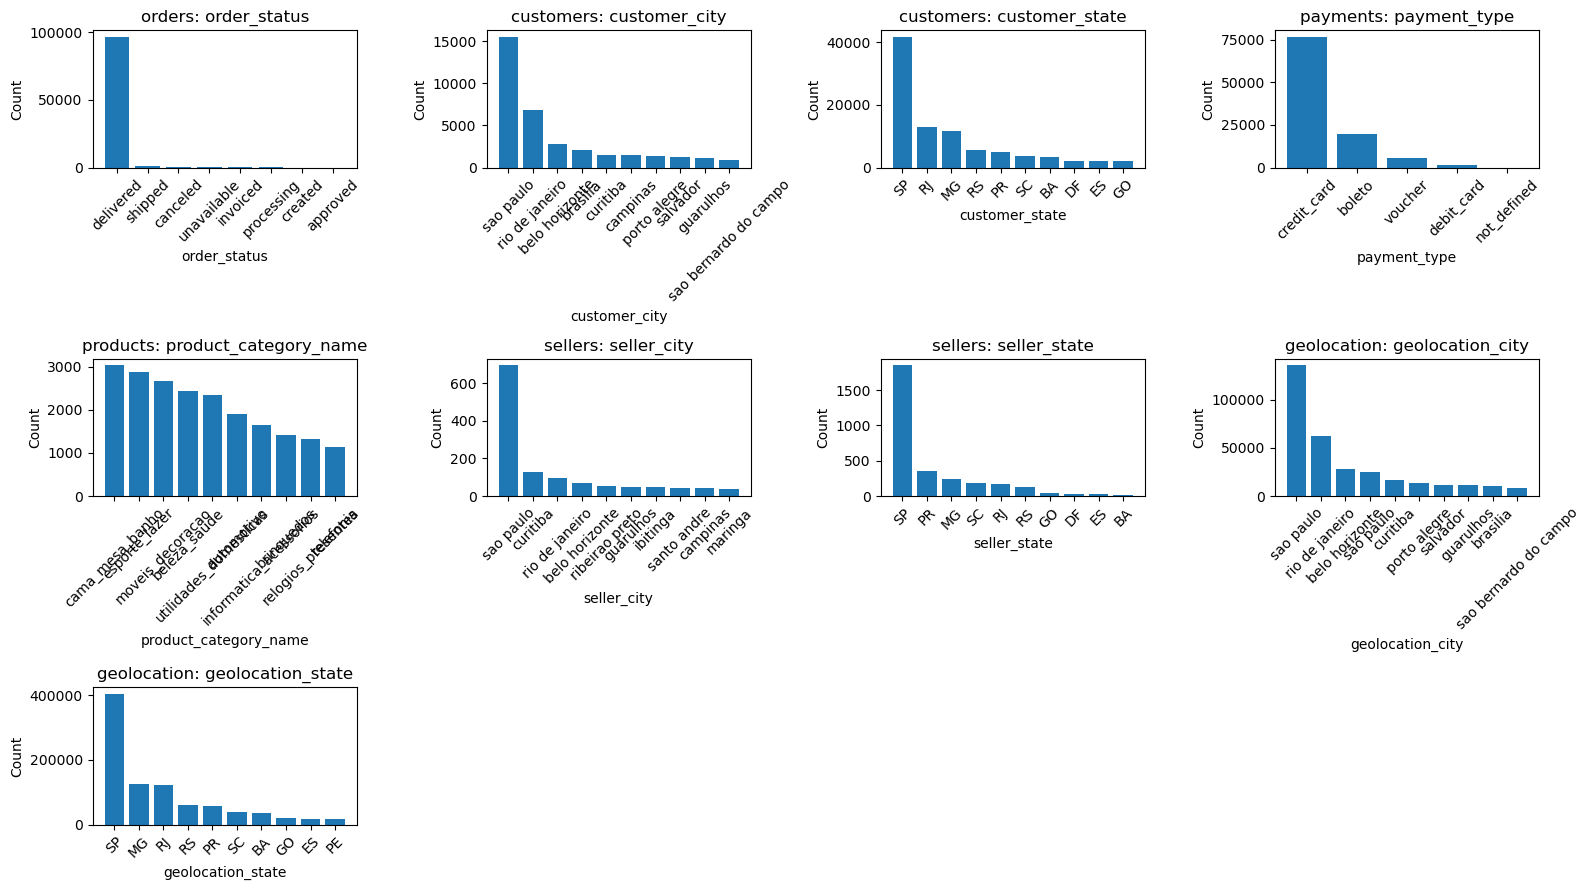

In [6]:
categorical_profile_columns = [
    {"dataset": row["dataset"], "column": row["column"]}
    for row in categorical_summary
]

n_cat_cols = 4
n_cat_rows = int(np.ceil(len(categorical_profile_columns) / n_cat_cols))

fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(16, 3 * n_cat_rows))
axes = axes.flatten()

for i, item in enumerate(categorical_profile_columns):
    dataset = item["dataset"]
    column = item["column"]

    value_counts = dfs[dataset][column].value_counts(dropna=False)

    if value_counts.shape[0] > 10:
        value_counts = value_counts.head(10)

    axes[i].bar(value_counts.index.astype(str), value_counts.values)

    axes[i].set_title(f"{dataset}: {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Summary

This notebook profiled the statistical shape and visual distribution of the Olist dataset across all meaningful numeric and categorical columns.

**Numeric profile** (14 columns across order_items, payments, reviews, products, geolocation) revealed expected right-skew in transaction values — `price`, `freight_value`, and `payment_value` all show mean significantly above median, consistent with a long tail of high-value purchases in a marketplace with predominantly low-to-mid range transactions. `review_score` clusters heavily at 5 with a mean of 4.09, confirming a positively skewed rating distribution typical of e-commerce platforms. Product dimensions and weight show wide variance, reflecting the breadth of categories sold.

**Categorical profile** (9 columns across orders, customers, payments, products, sellers, geolocation) confirmed São Paulo's dominance across the platform — SP accounts for the largest share of both customers (41,746) and sellers (1,849), and `sao paulo` is the most frequent city across customers, sellers, and geolocation. `credit_card` is the most common payment type (76,795 of 103,886 payment rows), and `delivered` accounts for 96,478 of 99,441 orders (97%).

**Visual analysis** confirmed the statistical findings: histograms show clear right-skew for all transaction value columns, boxplots make the outlier structure visible (particularly for `price`, `payment_value`, and `product_weight_g`), and bar charts highlight São Paulo's geographic concentration and credit card payment dominance.

All anomalies surfaced by the summary tables in this notebook were flagged inline and have been investigated and documented in `02_data_quality_check.ipynb`.

<hr style="height:2px; background-color:black; border:none;">